# Kapitel 9

In [1]:
from typing import Callable
type RealFun = Callable[[float],float]
import math

In [2]:
def NdirLimit(f:RealFun,x0:float, n=5, m=3,dir=1, eps=1e-5):
    def fk(k): return f(x0+dir*10**(-k))
    for k in range(n,n+m):
        if abs(fk(k+1)-fk(k))>eps:
            return False
    return fk(n+m)
def Nlimit(f:RealFun,x0:float, n=5, m=3, eps=1e-5):
    L=NdirLimit(f,x0, n=n, m=m, eps=eps, dir=-1)
    R=NdirLimit(f,x0, n=n, m=m, eps=eps, dir=1)
    if L==False or R==False: return False
    if abs(L-R)>eps: return False
    return (L+R)/2
def sinc(x): return math.sin(x)/x
print("sin(x)/x für x->0",Nlimit(sinc,0))
print("tan(x) für x->pi/2",Nlimit(math.tan,math.pi/2))
def f(x): return x**2
def Dq(h): return (f(1+h)-f(1))/h
print("Diff-Quot von x^2 bei x=1 für h->0: ",Nlimit(Dq,0))

sin(x)/x für x->0 1.0
tan(x) für x->pi/2 False
Diff-Quot von x^2 bei x=1 für h->0:  1.9999999933961732


In [3]:
def ableitung(f:RealFun,x:float,h=0.00001)->float:
    return (f(x+h)-f(x))/h

print("sin'(0)=",ableitung(math.sin,0))

sin'(0)= 0.9999999999833332


In [4]:
def Newton(f:RealFun,x0:float,eps=1e-8)->float:
    while abs(f(x0))>eps:
        x0+=-f(x0)/ableitung(f,x0)
    return x0
def NewtonR(f:RealFun,x0:float,eps=1e-8)->float:
    if abs(f(x0))<eps:
        return x0
    return NewtonR(f,x0-f(x0)/ableitung(f,x0),eps)
print("Newton-Pi",Newton(math.sin,2.5),NewtonR(math.sin,2.5))  

Newton-Pi 3.141592653609168 3.141592653609168


In [5]:
f1=lambda x : x**2
def f2(x):
    return x**2
print([f1(5),f2(5)])

[25, 25]


In [6]:
Newton(lambda x: x**2-2,1) # Newton mit einer anonymen Funktion

1.4142135623822438

In [7]:
def ableitung2(f:RealFun,x:float,h=0.000001)->float:
    return (f(x+h)-f(x-h))/(2*h)
print("sin'(1)=",ableitung2(math.sin,1),ableitung(math.sin,1),math.cos(1))

sin'(1)= 0.5403023058958567 0.5402980985058647 0.5403023058681398


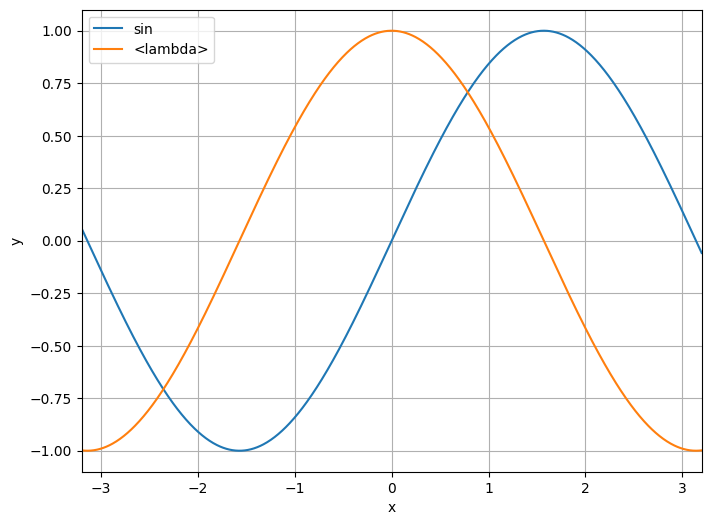

In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
def plotFun(fs: list, xmin, xmax, ymin, ymax):
    x = np.linspace(xmin, xmax, 1000)
    plt.figure(figsize=(8, 6))
    for f in fs:
        y = []
        for xi in x:
            try:
                y.append(f(xi))
            except Exception: 
                y.append(np.nan)  # Fehlerhafte Auswertung → Lücke im Plot
        plt.plot(x, y, label=f.__name__ if hasattr(f, '__name__') else str(f)) 
    plt.xlim(xmin, xmax); plt.ylim(ymin, ymax)
    plt.xlabel("x"); plt.ylabel("y")
    plt.grid(True); plt.legend(); plt.show()
    
def D(f:RealFun,h=0.00001)->RealFun:
    def fs(x):
        return ableitung2(f,x,h)
    return fs 
def D(f:RealFun,h=0.00001)->RealFun:
    return lambda x: ableitung2(f,x,h)
plotFun([math.sin,D(math.sin)], -3.2, 3.2, -1.1, 1.1)

In [9]:
def compose(f:Callable,g:Callable)->Callable:
    return lambda x: f(g(x))
def iterate(f:Callable,n:int)->Callable:
    if n==0:
        return lambda x: x
    return compose(f,iterate(f,n-1))
def nTeAbl(f,n):
    return iterate(D,n)(f)
[[j,nTeAbl(math.sin,j)(0)] for j in range(4)]

[[0, 0.0], [1, 0.9999999999833332], [2, 0.0], [3, -0.9999989725173463]]

In [10]:
def ZweiteAbl(f:RealFun,x:float,h=0.00001)->float:
    return (f(x+h)-2*f(x)+f(x-h))/h**2
ZweiteAbl(math.cos,0)

-1.0000000827403708

In [11]:
def Bisektion(f:RealFun,a:float,b:float,eps=1e-8)->float:
    if f(a)*f(b)>0:
        raise Exception("Bisektion braucht unterschiedliche Vorzeichen")
    while abs(a-b)>eps:
        m=(a+b)/2 
        if f(a)*f(m)<0: # Nst zwischen a und m
            b=m
        else:
            a=m
    return m
def NullAuto(f:RealFun,a:float,b:float, n=100,eps=1e-6,small=0.01)->list[float]:
    x1=a; delta=(b-a)/n; x2=x1+delta
    sols=[]
    while x1<b:
        if f(x1)*f(x2)<0:
            sols.append(Bisektion(f,x1,x2,eps))
        else:
            if abs(f(x1))<small: sols.append(Newton(f,x1))
        x1=x2; x2+=delta;
    return sols
print("Sinus-Nullstellen",NullAuto(math.sin,-10,10))
print("Sinus-1-Nullstellen",NullAuto(lambda x: math.sin(x)-1, -10,10))        

Sinus-Nullstellen [-9.424777984619144, -6.283185577392584, -3.1415931701660185, 7.629394510710874e-07, 3.141593170166014, 6.283185577392579, 9.424777984619137]
Sinus-1-Nullstellen [-4.712469367279131, -4.712274457707076, 1.5709153028517953, 7.853881307884714]


In [12]:
def Integral0(f:RealFun,a,b,n=1000):
    dx=(b-a)/n
    return sum([f(a+i*dx)*dx for i in range(n)])
print("Integral0 über sin 0..PI",Integral0(math.sin,0,math.pi))
def Integral(f:RealFun,a:float,b:float,n=1000,m=0.5)->float:
    # m=0: Linkssumme, m=1 Rechtssumme, m=0.5: Mittelsummen
    if a>b:
        return -Integral(f,b,a,n,m)
    dx=(b-a)/n
    return sum([f(a+(i+m)*dx)*dx for i in range(n)])
print("Integral über sin 0..PI",Integral(math.sin,0,math.pi))

Integral0 über sin 0..PI 1.9999983550656626
Integral über sin 0..PI 2.0000008224672703


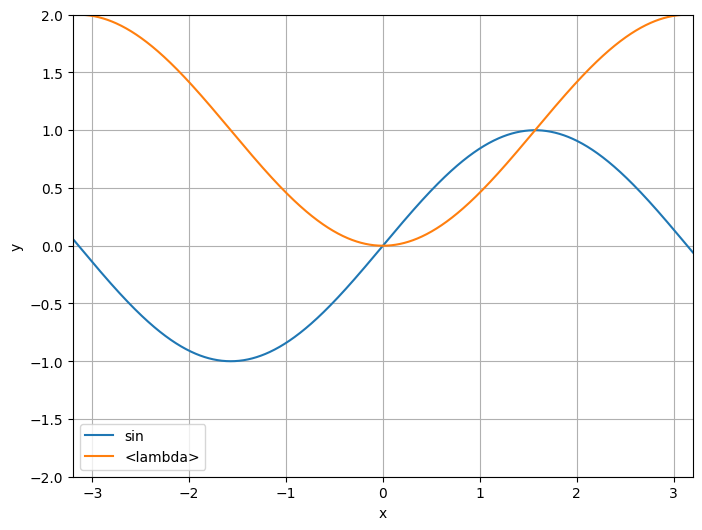

In [13]:
def IntegralFunktion(f:RealFun,a:float)->RealFun:
    return lambda x: Integral(f,a,x)
plotFun([math.sin,IntegralFunktion(math.sin,0)], -3.2, 3.2, -2, 2)

In [14]:
def Simpson(f:RealFun,a:float,b:float,n=100)->float:
    if a>b:
        return -Integral(f,b,a,n)
    dx=(b-a)/n
    return sum([(f(a+i*dx) + 4*f(a+(i+1/2)*dx) + f(a+(i+1)*dx))*dx/6 for i in range(n)])
print("Integral über sin 0..PI mit Simpson",Simpson(math.sin,0,math.pi,n=100))
print("Integral über sin 0..PI mit Rechtecken",Integral(math.sin,0,math.pi,n=100))

Integral über sin 0..PI mit Simpson 2.0000000006764718
Integral über sin 0..PI mit Rechtecken 2.000082249070986


In [15]:
def Euler(g,x0,y0,xe,n=100):
    dx=(xe-x0)/n
    xs=[x0]; ys=[y0]
    for i in range(1,n+1):
        y=ys[-1]; x=x0+i*dx; 
        xs.append(x)
        ys.append(y+dx*g(x,y))
    return [xs,ys]
# Beispiel: Exponentielles Wachstum
def gExpo(x,y): return 0.2*y
Euler(gExpo,0,1,5,n=20) # Am Ende liefert das e - mit großem Fehler

[[0,
  0.25,
  0.5,
  0.75,
  1.0,
  1.25,
  1.5,
  1.75,
  2.0,
  2.25,
  2.5,
  2.75,
  3.0,
  3.25,
  3.5,
  3.75,
  4.0,
  4.25,
  4.5,
  4.75,
  5.0],
 [1,
  1.05,
  1.1025,
  1.1576250000000001,
  1.2155062500000002,
  1.2762815625000004,
  1.3400956406250004,
  1.4071004226562505,
  1.477455443789063,
  1.5513282159785162,
  1.628894626777442,
  1.7103393581163142,
  1.7958563260221299,
  1.8856491423232364,
  1.9799315994393982,
  2.0789281794113683,
  2.182874588381937,
  2.2920183178010336,
  2.406619233691085,
  2.5269501953756395,
  2.6532977051444213]]

In [16]:
def RungeKutta(g,x0,y0,xe,n=100):
    dx=(xe-x0)/n
    xs=[x0]; ys=[y0]
    for i in range(1,n+1):
        y=ys[-1]
        x=x0+i*dx; xm=x+dx/2; x1=x+dx
        xs.append(x)
        k1=g(x,y); k2=g(xm,y+k1*dx/2)
        k3=g(xm,y+k2*dx/2); k4=g(x1,y+k3*dx)
        ys.append(y+dx/6*(k1+2*k2+2*k3+k4))
    return [xs,ys]
# Beispiel: Exponentielles Wachstum
def gExpo(x,y): return 0.2*y
RungeKutta(gExpo,0,1,5,n=20) # Am Ende liefert das e

[[0,
  0.25,
  0.5,
  0.75,
  1.0,
  1.25,
  1.5,
  1.75,
  2.0,
  2.25,
  2.5,
  2.75,
  3.0,
  3.25,
  3.5,
  3.75,
  4.0,
  4.25,
  4.5,
  4.75,
  5.0],
 [1,
  1.05127109375,
  1.1051709125543214,
  1.1618342340216672,
  1.2214027459561516,
  1.284025400650577,
  1.3498587873447139,
  1.419067523779926,
  1.4918246678292268,
  1.5683121502320618,
  1.648721229515874,
  1.7332529702419976,
  1.8221187457717412,
  1.9155407668098365,
  2.0137526370468906,
  2.1169999372902315,
  2.225540839543783,
  2.339646752572486,
  2.4596030005655134,
  2.585709536595289,
  2.718281692656335]]

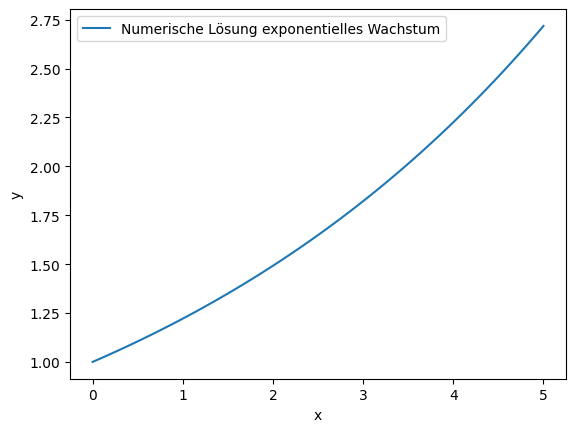

In [17]:
import numpy as np
import matplotlib.pyplot as plt
[xs,ys]=RungeKutta(gExpo,0,1,5)
plt.plot(xs, ys, label="Numerische Lösung exponentielles Wachstum")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

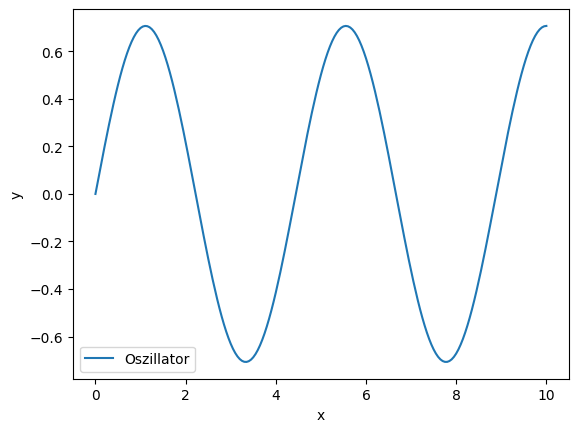

In [18]:
def RungeKuttaSys(g, x0, y0, xe, n=100):
    dx = (xe - x0) / n
    xs = [x0]
    ys = [np.array(y0, dtype=float)] 
    for i in range(1, n+1):
        y = ys[-1]
        x=x0+i*dx; xm=x+dx/2; x1=x+dx
        xs.append(x)
        k1 = g(x,y); k2 = g(xm, y + k1*dx/2)
        k3 = g(xm, y + k2*dx/2); k4 = g(x1, y + k3*dx)
        ys.append(y + dx/6*(k1 + 2*k2 + 2*k3 + k4))
    return [xs, ys]
def g_harm(x, y): # Harmonischer Oszillator
    # y = [f, f']
    return np.array([y[1], -2*y[0]], dtype=float)
[xs, ys] = RungeKuttaSys(g_harm, 0.0, [0.0, 1.0], 10.0, n=200)
# f(x) ist die erste Komponente:
plt.plot(xs, [v[0] for v in ys], label="Oszillator")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

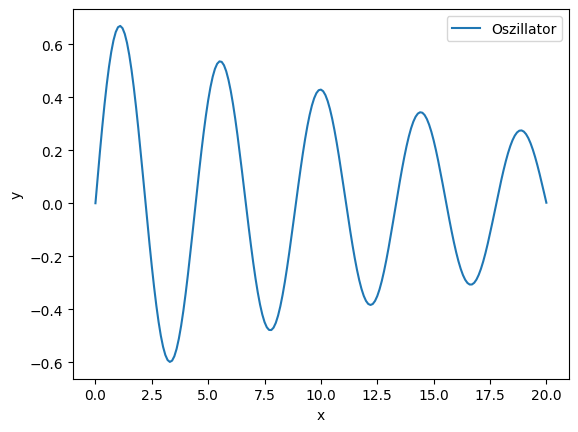

In [19]:
def g_harm(x, y): # Harmonischer Oszillator mit Dämpfung
    return np.array([y[1], -2*y[0]-0.1*y[1]], dtype=float)
[xs, ys] = RungeKuttaSys(g_harm, 0.0, [0.0, 1.0], 20.0, n=200)
# f(x) ist die erste Komponente:
plt.plot(xs, [v[0] for v in ys], label="Oszillator")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

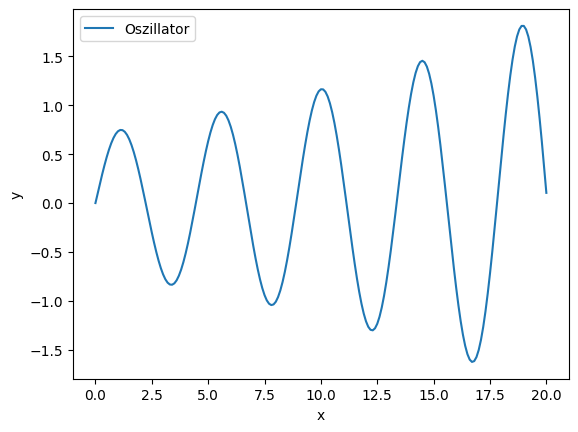

In [20]:
# Zum Vergleich das einfache Euler-Verfahren, das am Oszillator scheitert
def EulerSys(g, x0, y0, xe, n=100):
    dx = (xe - x0) / n
    xs = [x0]
    ys = [np.array(y0, dtype=float)] 
    for i in range(1, n+1):
        y = ys[-1]; x=xs[-1]
        xs.append(x+dx)
        ys.append(y + dx*g(x,y))
    return [xs, ys]
[xs, ysE] = EulerSys(g_harm, 0.0, [0.0, 1.0], 20.0, n=200)
plt.plot(xs, [v[0] for v in ysE], label="Oszillator")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

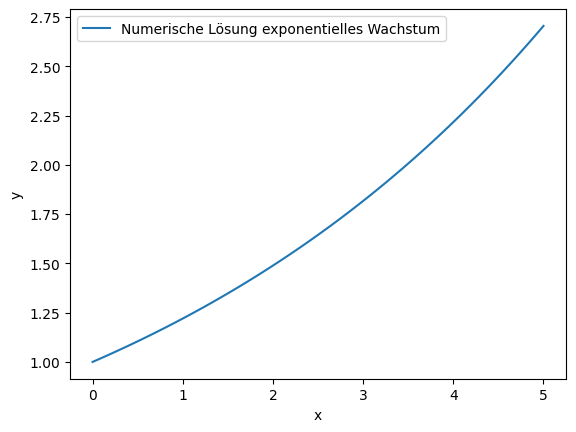

In [21]:
# Das exponentielle Wachstum aber funktioniert auch mit dem Euler-Verfahren
[xs,ys]=EulerSys(gExpo,0,1,5)
plt.plot(xs, ys, label="Numerische Lösung exponentielles Wachstum")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

Gefundene Anfangssteigung s = f'(0) ≈ 74.203210577718


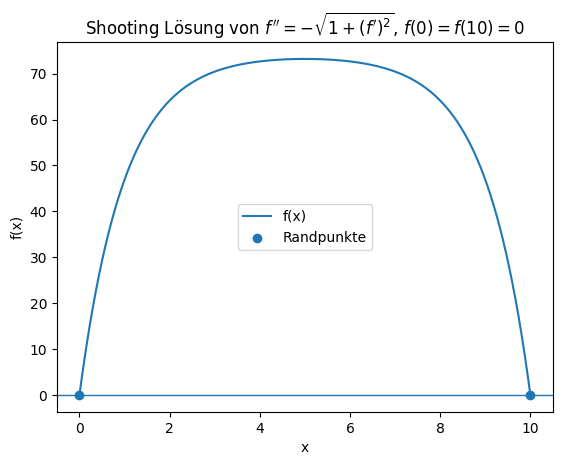

In [22]:
# Das Folgende ist eine Ergänzung, die nicht im Buch beschrieben wird. 
# Es wird gezeigt, wie man ein Randwertproblem mit der Shooting-Methode lösen kann.
# Das Beispiel ist die DGL eines frei stehenden oder hängenden Bogens.
# Gesucht ist die Form, bei der die Gewichtskraft Kräfte tangential zum Bogen erzeugt.
def shoot_F(make_y0_from_s, g, x0, xe, n, boundary_value, s):
    # Integriert die DGL für einen Startwert, der durch s parametriert wird
    # Ziel ist F(s) = boundary_value(y_end)
    # boundary_value ist eine Zhal y_end[0] - Ziel.
    y0 = make_y0_from_s(s)
    xs, ys = RungeKuttaSys(g, x0, y0, xe, n)
    y_end = ys[-1]
    return float(boundary_value(y_end))

# Suche richtigen Wert von s durch Intervallschachtelung 
# Eine bracket ist ein Intervall [sL,sR], das F(sL)*F(sR) <= 0 erfüllt
def find_bracket(make_y0_from_s, g, x0, xe, n, boundary_value, sL=0.0, sR=1.0, max_expand=60):
    FL = shoot_F(make_y0_from_s, g, x0, xe, n, boundary_value, sL)
    FR = shoot_F(make_y0_from_s, g, x0, xe, n, boundary_value, sR)
    if FL == 0.0: return [sL, sL]
    if FL * FR <= 0.0: return [sL, sR]
    for j in range(max_expand):
        sR *= 2.0
        FR = shoot_F(make_y0_from_s, g, x0, xe, n, boundary_value, sR)
        if FL * FR <= 0.0: return [sL, sR]
    raise RuntimeError("Kein Bracketing-Intervall gefunden. (Andere Startwerte oder n erhöhen)")

def bisect_root(make_y0_from_s, g, x0, xe, n, boundary_value, sL=0.0, sR=1.0, tol=1e-10, maxit=100):
    [sL, sR] = find_bracket(make_y0_from_s, g, x0, xe, n, boundary_value, sL, sR)
    if sL == sR: return sL
    FL = shoot_F(make_y0_from_s, g, x0, xe, n, boundary_value, sL)
    FR = shoot_F(make_y0_from_s, g, x0, xe, n, boundary_value, sR)
    for j in range(maxit):
        sM = 0.5 * (sL + sR)
        FM = shoot_F(make_y0_from_s, g, x0, xe, n, boundary_value, sM)
        if abs(FM) < tol: return sM
        if FL * FM <= 0.0:
            sR, FR = sM, FM
        else:
            sL, FL = sM, FM
    return 0.5 * (sL + sR)
# Beispiel-Randwertproblem:
# f'' = -sqrt(1+(f')^2), f(0)=0, f(10)=0
# System: y = [f, v] mit v=f'
# y' = [v, -sqrt(1+v^2)]
# Shooting-Parameter: s = v(0)
def g_system(x, y):
    f=y[0]; v = y[1]
    return np.array([v, -np.sqrt(1.0 + v*v)], dtype=float)

x0=0.0; xe=10.0; n=4000

def make_y0_from_s(s):
    # f(0)=0 fest, v(0)=s geraten
    return np.array([0.0, s], dtype=float)

def boundary_value(y_end):
    # Randbedingung f(10)=0
    return y_end[0] - 0.0

# Shooting: finde s so, dass f(10)=0
s_star = bisect_root(make_y0_from_s, g_system, x0, xe, n, boundary_value, sL=0.0, sR=1.0)
print(f"Gefundene Anfangssteigung s = f'(0) ≈ {s_star:.12f}")

# Lösungskurve mit diesem s integrieren
xs, ys = RungeKutta(g_system, x0, make_y0_from_s(s_star), xe, n)
f_vals = np.array([y[0] for y in ys], dtype=float)
v_vals = np.array([y[1] for y in ys], dtype=float)
# Plot
plt.figure(); 
plt.plot(xs, f_vals, label="f(x)")
plt.axhline(0.0, linewidth=1)
plt.scatter([x0, xe], [0.0, 0.0], zorder=3, label="Randpunkte")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.title(r"Shooting Lösung von $f''=-\sqrt{1+(f')^2}$, $f(0)=f(10)=0$")
plt.legend(); plt.show()


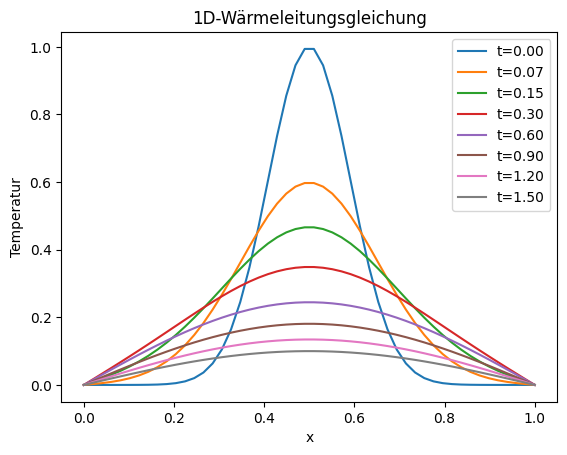

In [23]:
# Wärmeleitungsgleichung
# Raumdiskretisierung
L = 1.0; N = 50
dx = L / (N - 1)
xs = np.linspace(0, L, N) 
# Anfangstemperatur (z.B. "Wärmeberg")
T0 = np.exp(-60*(xs-0.5)**2)
# Randbedingungen fest
T0[0] = 0.0; T0[-1] = 0.0
kappa = 0.1
def heat_rhs(t, T, kappa, dx):
    dT = np.zeros_like(T)
    for i in range(1, len(T)-1):
        dT[i] = kappa * (T[i+1] - 2*T[i] + T[i-1]) / dx**2
    return dT
def g_heat(t,T):
    return heat_rhs(t, T, kappa, dx)
t0 = 0.0; te = 1.5; nsteps = 1000
[ts, Ts] = RungeKuttaSys(g_heat, t0, T0, te, nsteps)
# Plot einiger Zeitpunkte
plt.figure()
for i in [0, 50,100,200, 400, 600,800,1000]:
    plt.plot(xs, Ts[i], label=f"t={ts[i]:.2f}")
plt.xlabel("x"); plt.ylabel("Temperatur")
plt.title("1D-Wärmeleitungsgleichung")
plt.legend(); plt.show()